# Домашнее задание 3. VAE + NF + VAPNEV

В этом задании вам предстоит поработать с набором данных CelebA. Решение домашней работы должно быть представлено в виде .zip архива, содержащего:
- Jupyter Notebook(и) и/или модули с кодом,
- PDF-отчет, в котором необходимо описать проведённые эксперименты, а также обосновать выбор используемых методов (например, дополнительные лоссы для стабилизации, виды потоков, особенности реализации VAE и пр.).

## Настройка окружения

In [2]:
import sys
sys.path.append('../seminars/utils/')  # Добавляем путь к CelebADataset

import torch
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as np

from datasets.celeba import CelebADataset

# Set device
cuda = torch.cuda.is_available()
device = torch.device("cuda" if cuda else ("mps" if torch.backends.mps.is_available() else "cpu"))
torch.backends.cudnn.benchmark = cuda

print(f"Using device: {device}")

Using device: mps


## Загрузка данных

In [3]:
# Определение трансформаций

t_normalize = lambda x: x * 2 - 1
t_invnormalize = lambda x: (x + 1) / 2

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    t_normalize,
])

In [9]:
# Кастомный датасет CelebA, возвращающий только изображения

class CelebaCustomDataset(CelebADataset):
    def __getitem__(self, idx):
        image, _ = super().__getitem__(idx)
        return image

dataset = CelebaCustomDataset(
    transform=transform,
    root_dir='../seminars/data/celeba',
)

# Пример получения изображения
img = dataset[0]
print("Размер изображения:", img.shape)

Размер изображения: torch.Size([3, 64, 64])


### Визуализация датасета

In [10]:
def plot_img(img, transform):
    plt.imshow(transform(img).permute(1, 2, 0))
    plt.axis('off')

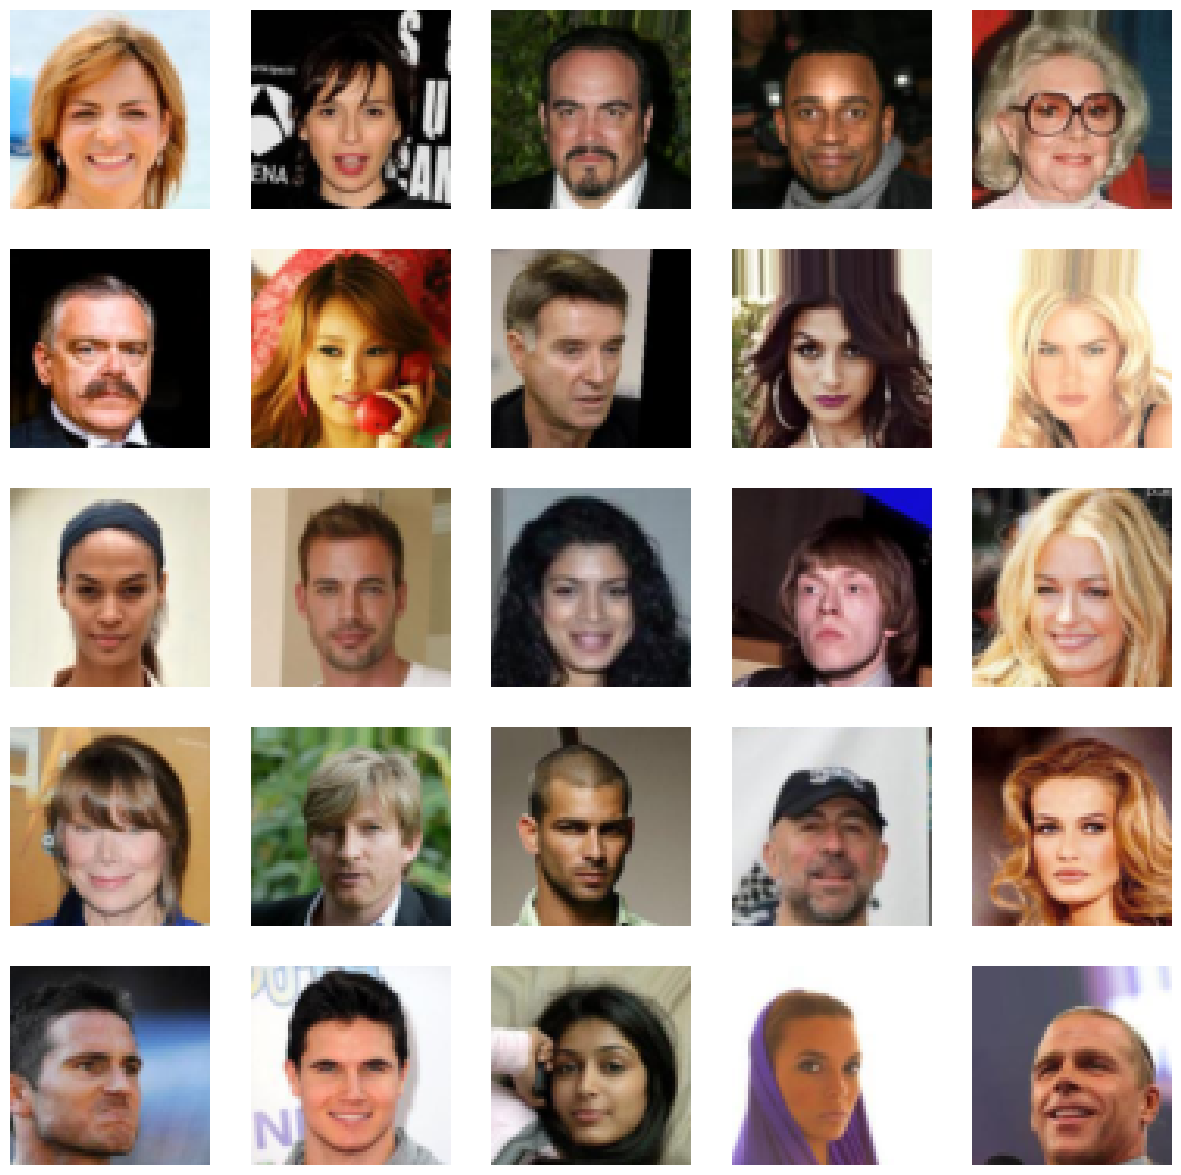

In [11]:
plt.figure(figsize=(15, 15))
for i in range(25):
    random_idx = np.random.randint(len(dataset))
    img = dataset[random_idx]
    plt.subplot(5, 5, i + 1)
    plot_img(img, t_invnormalize)
plt.show()

### Задача 1 (4/13 баллов): Построение и обучение нормального потока (Normalizing Flow) на CelebA

Необходимо обучить нормальный поток до качества, удовлетворяющего базовым порогам (точные пороги будут предоставлены позже). 

Измерьте FID и Negative Log Likelihood для оценки модели.

Внутри потока можно использовать любые компоненты: Coupling/Autoregressive/Linear слои, произвольные трансформации и т.д. Главное — реализовать их самостоятельно без копипаста.

Можно использовать как сверточные потоки (обычно дают лучшие результаты, но сложнее реализуются), так и линейные потоки (будут менее качественными), при этом можно предварительно свести изображение к вектору.

Можно использовать готовый код из репозитория курса, но рекомендуется написать свою реализацию.

In [12]:
# TODO: Реализуйте нормальный поток для CelebA.

### Задача 2 (2/13 баллов): Построение и обучение VAE на CelebA

Обучите вариационный автоэнкодер (VAE) до достижения приемлемого качества генерации. Измерьте FID и сохраните результаты для дальнейшего сравнения.

Можно использовать готовые решения из репозитория курса, но предпочтительно написать свою реализацию.

In [13]:
# TODO: Реализуйте VAE для CelebA.

### Задача 3 (6/13 баллов)

#### Задача 3.1 (4 балла): Построение и обучение VAPNEV на CelebA

Изучите статью [VAPNEV](https://arxiv.org/pdf/1611.05209.pdf), реализуйте и обучите модель до качества, удовлетворяющего базовым порогам (точные пороги будут предоставлены позже). Измерьте FID и сохраните результаты.

#### Задача 3.2 (2 балла): Построение и обучение conditional VAPNEV на CelebA

Реализуйте условный (conditional) вариант VAPNEV. Подробности можно найти в описании задачи и в статье.

In [14]:
# TODO: Реализуйте VAPNEV и conditional VAPNEV для CelebA.

### Задача 4 (1/13 баллов): Анализ

Проведите анализ латентного пространства и оцените качество генерации:
1. Определите, у какой модели лучше интерполируется латентное пространство.
2. Попробуйте взять внешнее изображение (не из CelebA), отобразить его в латентное пространство и найдите ближайшие по значению векторы.
3. Продемонстрируйте самый интересный (или забавный) результат генерации, который у вас получался.

In [15]:
# TODO: Добавьте код для анализа латентного пространства и демонстрации результатов.

### Задача 0: Отчет

Для получения полного балла по каждому пункту задания необходимо включить в отчет (предоставляемый отдельно в формате PDF) примеры генераций моделей. 

Сравните результаты различных моделей, постарайтесь объяснить, почему одни подходы работают лучше других.